# Comparison of Results Between Models
The following serves as algorithm:
1. Load .csv file for each variable
2. Error check
3. For each csv variable, create pd.Dataframe (rows=metrics, columns=models)
4. Using dataframe from previous step, create Matplotlib (grouped bar chart displaying performances of each model on each metric)
5. Add narratives, interpretations on results
6. Ranking for each model (1st - model name, 2nd - model name, …. 4th- model name).

In [18]:
# import necessary libraries
import joblib
import pandas as pd
from sklearn.metrics import (
    balanced_accuracy_score, classification_report,
    roc_auc_score, precision_recall_curve, auc, accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns

lg_csv = pd.read_csv('model_outputs/lg_test_predictions.csv')
rf_csv = pd.read_csv('model_outputs/rf_test_predictions.csv')
gb_csv = pd.read_csv('model_outputs/gb_test_predictions.csv')
mlp_csv = pd.read_csv('model_outputs/mlp_test_predictions.csv')

Check errors. The predicted probability for each csv file must be the probability that it is urban (1). If a predicted probability value is >=0.5, then the corresponding value in predicted class value must be 1.  

In [19]:
def error_check(predictedClass_col, predictedProb_col, threshold=0.5):
    ctr = 0
    for a, b in zip(predictedClass_col, predictedProb_col):
        if b >= threshold:
            if a==0:
                ctr += 1
        else:
            if a==1:
                ctr += 1
    return ctr

lg_threshold = joblib.load('model_outputs/logistic_regression_threshold.pkl')

print("Error Check Count")
print(f"  Logistic Regression    = {error_check(lg_csv["LG_Predicted_Class"], lg_csv["LG_Predicted_Probability"], lg_threshold)}")
print(f"  Random Forest          = {error_check(rf_csv["RF_Predicted_Class"], rf_csv["RF_Predicted_Probability"])}")
print(f"  Gradient Boosting      = {error_check(gb_csv["GB_Predicted_Class"], gb_csv["GB_Predicted_Probability"])}")
print(f"  Multi-Layer Perceptron = {error_check(mlp_csv["MLP_Predicted_Class"], mlp_csv["MLP_Predicted_Probability"])}")

Error Check Count
  Logistic Regression    = 0
  Random Forest          = 0
  Gradient Boosting      = 0
  Multi-Layer Perceptron = 0


Creating Pandas Series to get evaluation metrics for each model and then appending them together to create a dataframe

In [20]:
def model_eval(model_name, y_actual, y_pred, y_prob):
    bal_acc = balanced_accuracy_score(y_actual, y_pred)
    acc = accuracy_score(y_actual, y_pred)
    report = classification_report(y_actual, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_actual, y_prob)
    precision_vals, recall_vals, _ = precision_recall_curve(y_actual, y_prob)
    pr_auc = auc(recall_vals, precision_vals)

    data_index = {
        'Balanced Accuracy': round(bal_acc, 4),
        'Accuracy': round(acc, 4), 
        'Precision (Rural)': round(report['0']['precision'], 4), 
        'Precision (Urban)': round(report['1']['precision'], 4),
        'Recall (Rural)': round(report['0']['recall'], 4), 
        'Recall (Urban)': round(report['1']['recall'], 4), 
        'F1-score (Rural)': round(report['0']['f1-score'], 4), 
        'F1_score (Urban)': round(report['1']['f1-score'], 4),
        'ROC-AUC': round(roc_auc, 4),
        'PR-AUC': round(pr_auc, 4)
    }
    return pd.DataFrame.from_dict(data_index, orient='index', columns=[model_name])


lg_sr = model_eval("Logistic Regression", lg_csv["Actual_y_test"], lg_csv["LG_Predicted_Class"], lg_csv["LG_Predicted_Probability"])
rf_sr = model_eval("Random Forest", rf_csv["Actual_y_test"], rf_csv["RF_Predicted_Class"], rf_csv["RF_Predicted_Probability"])
gb_sr = model_eval("Gradient Boosting", gb_csv["Actual_y_test"], gb_csv["GB_Predicted_Class"], gb_csv["GB_Predicted_Probability"])
mlp_sr = model_eval("Multi-Layer Perceptron", mlp_csv["Actual_y_test"], mlp_csv["MLP_Predicted_Class"], mlp_csv["MLP_Predicted_Probability"])

model_df = pd.concat([lg_sr, rf_sr, gb_sr, mlp_sr], axis=1)
model_df

,Logistic Regression,Random Forest,Gradient Boosting,Multi-Layer Perceptron
Balanced Accuracy,0.7950,0.7899,0.8059,0.7958
Accuracy,0.7995,0.8183,0.8276,0.8161
Precision (Rural),0.8542,0.8162,0.8349,0.8303
Precision (Urban),0.7214,0.8229,0.8131,0.7891
Recall (Rural),0.8142,0.9108,0.8984,0.8825
Recall (Urban),0.7758,0.6691,0.7134,0.7090
F1-score (Rural),0.8337,0.8609,0.8655,0.8556
F1_score (Urban),0.7476,0.7381,0.7600,0.7469
ROC-AUC,0.8833,0.8849,0.8995,0.8903
PR-AUC,0.8537,0.8562,0.8725,0.8618


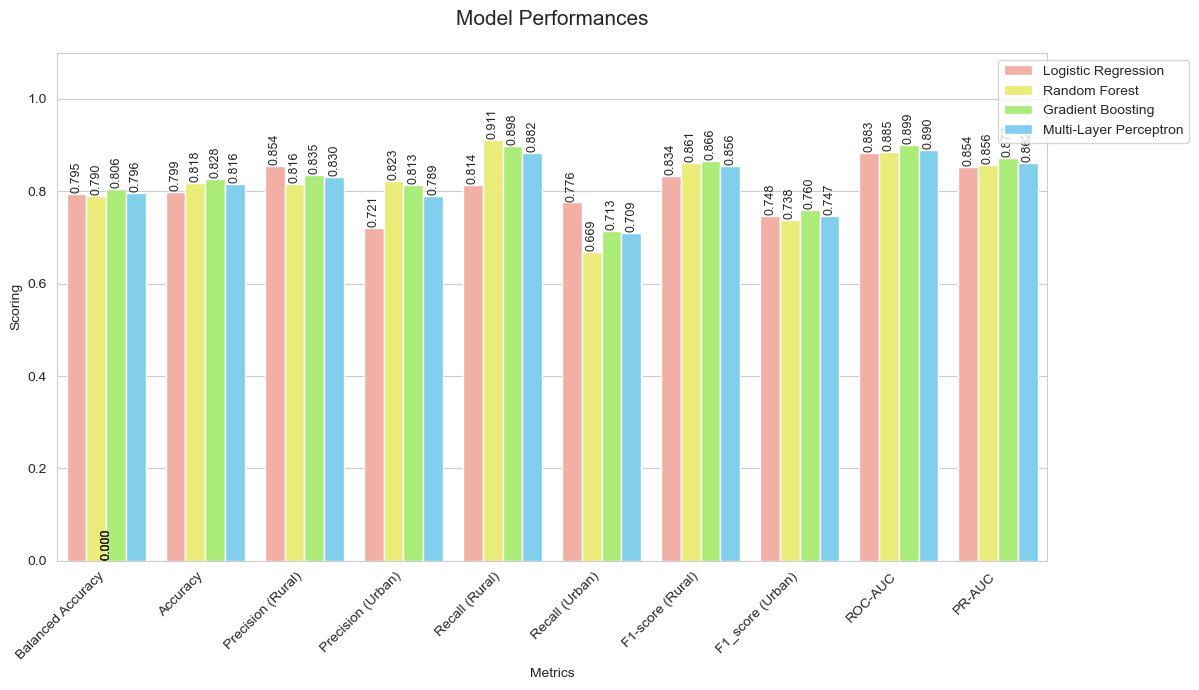

In [21]:

plot_data = model_df
plot_data = plot_data.reset_index().melt(id_vars='index', var_name='Model Stage', value_name='Score')
plot_data.columns = ['Metric', 'Model Stage', 'Score']

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
    
ax = sns.barplot(data=plot_data, x='Metric', y='Score', hue='Model Stage', palette=["#ffa599","#fcff66", "#a8ff66", "#6fd6ff"])
    
plt.title("Model Performances", fontsize=15, pad=20)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1) # Scores are between 0 and 1
plt.ylabel("Scoring")
plt.xlabel("Metrics")
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 12), 
                textcoords = 'offset points',
                fontsize=9, rotation=90)
plt.tight_layout()
plt.show()

In [22]:
# Comparing of metrics
ctr_lr = 0
ctr_rf = 0
ctr_gb = 0
ctr_mlp = 0

for m1,m2,m3,m4 in zip(lg_sr.iloc[:, 0], rf_sr.iloc[:, 0], gb_sr.iloc[:, 0], mlp_sr.iloc[:, 0]):
    highest_value = max(m1, m2, m3, m4)
    if highest_value==m1:
        ctr_lr += 1
    elif highest_value==m2:
        ctr_rf += 1
    elif highest_value==m3:
        ctr_gb += 1
    elif highest_value==m4:
        ctr_mlp += 1

data_index = {
    'LogisticRegression': ctr_lr,
    'RandomForest': ctr_rf,
    'GradientBoosting': ctr_gb,
    'MultiLayerPerceptron': ctr_mlp
}

ranking_df = pd.DataFrame.from_dict(data_index, orient='index', columns=['Count'])
ranking_df = ranking_df.sort_values(by='Count', ascending=False)
ranking_df

,Count
GradientBoosting,6
LogisticRegression,2
RandomForest,2
MultiLayerPerceptron,0


After comparing the metrics, it can be observed that gradient boosting achieved the greatest score in the most metrics. Among the models it achieved the highest balanced accuracy, accuracy, f1-score on rural households, ROC-AUC, and PR-AUC.

<hr/>

# AI Declaration
Chavez, Allen Visagar
- sample text

Llanes, Andre Gabriel De Ocampo
- sample text

Rojo, Von Matthew De Guzman *(leader)*
- Uses Google-search that has AI features in synthesizing different sources relevant to questions I asked.
- Uses Google Gemini to ask ways on how to import CSV dataset and scaffolding ideas for EDA
- Used Google Gemini for evaluating if code implementation is correct in terms of hyperparameter tuning.
- Used Google Gemini to generate code for visual graphs

Tan, Jeremy James Teves
- Uses ChatGPT to clarify proper flow for training loop
- Uses ChatGPT to assist with understanding errors that came up during debugging
- Uses ChatGPT to clarify errors in python syntax for neural network implementation and training
- Uses Google-search which has AI features in finding sources to justify approaches